# **Image Classification using a Convolutional Neural Network on CIFAR-10 Dataset**

**OBJECTIVE**

The objective of this project is to develop a deep learning model for multi-class image classification using a Convolutional Neural Network (CNN). The model is trained on the CIFAR-10 dataset to classify images into ten object categories. The performance of the model is evaluated using standard classification metrics such as accuracy, precision, recall, F1-score, confusion matrix, and ROC curve.

**PROBLEM STATEMENT**

Image classification is an important task in computer vision where a model must correctly identify objects present in an image. Traditional machine learning techniques struggle to extract complex visual patterns from image data. Deep learning models such as Convolutional Neural Networks (CNNs) are capable of automatically learning hierarchical features from images through multiple layers of processing. In this project, a CNN-based model is developed to classify images from the CIFAR-10 dataset into ten different categories and evaluate its performance using various classification metrics.

**Overview of the Proposed Method**

The proposed method aims to develop an image classification system using a Convolutional Neural Network. The CIFAR-10 dataset is used for training and evaluating the model, which contains images belonging to ten different object categories.

Initially, the dataset is preprocessed by normalizing the pixel values so that they fall within the range of 0 to 1. This helps improve the stability and efficiency of the training process. The class labels are converted into categorical format using one-hot encoding to support multi-class classification.

A CNN architecture consisting of multiple convolutional layers, pooling layers, and fully connected layers is then designed to automatically extract features from the input images. The convolutional layers learn spatial features such as edges, textures, and patterns, while pooling layers reduce the spatial dimensions and computational complexity.

The model is trained using the training dataset and evaluated on the testing dataset. The performance of the model is analyzed using evaluation metrics such as accuracy, precision, recall, F1-score, confusion matrix, and ROC curve to assess the effectiveness of the classification system.

**Dataset Description**

The dataset used in this project is the CIFAR-10 dataset, which is a widely used benchmark dataset for evaluating image classification models in deep learning. It was developed by Alex Krizhevsky and is commonly used in computer vision research.

The dataset consists of 60,000 color images divided into 10 different object categories. Each image has a size of 32 × 32 pixels and contains three color channels (RGB). Out of the total images, 50,000 images are used for training the model and 10,000 images are used for testing the model.

The ten classes present in the dataset are:

Airplane

Automobile

Bird

Cat

Deer

Dog

Frog

Horse

Ship

Truck

Each class contains 6,000 images, ensuring a balanced distribution across all categories. The dataset provides a suitable benchmark for evaluating the performance of deep learning models for multi-class image classification tasks.

**Dataset Preprocessing**

Before training the deep learning model, several preprocessing steps were applied to prepare the dataset for effective learning. Preprocessing is an important step in deep learning as it helps improve the quality of the input data and ensures that the model can learn meaningful patterns from the images.

First, the image data was normalized by scaling the pixel values from the original range of 0 to 255 to the range 0 to 1. This was achieved by dividing each pixel value by 255. Normalization helps improve the numerical stability of the training process and allows the neural network to converge faster during training.

Next, the class labels were converted into categorical format using one-hot encoding. Since the CIFAR-10 dataset contains ten different classes, one-hot encoding represents each class label as a binary vector of length ten. This encoding is necessary for multi-class classification problems where the model predicts the probability of each class using the Softmax activation function.

After preprocessing the input images and labels, the dataset was divided into training and testing sets. The training dataset is used to train the convolutional neural network, allowing the model to learn patterns and features from the images. The testing dataset is used to evaluate the performance of the trained model on unseen data.

These preprocessing steps ensure that the dataset is properly formatted and suitable for training the convolutional neural network for the image classification task.

**Model Architecture and Hyperparameters**

In this project, a Convolutional Neural Network (CNN) architecture is implemented to perform image classification on the CIFAR-10 dataset. CNNs are widely used in computer vision tasks because they can automatically learn spatial features from image data through convolutional operations.

The proposed CNN architecture consists of multiple convolutional layers followed by pooling layers and fully connected layers. The convolutional layers extract important features such as edges, shapes, and textures from the images, while the pooling layers reduce spatial dimensions and computational complexity.

The architecture of the model is as follows:

Input Layer (32 × 32 × 3 image)

↓

Convolution Layer (32 filters, 3×3 kernel, ReLU activation)

↓

Max Pooling Layer (2×2)

↓

Convolution Layer (64 filters, 3×3 kernel, ReLU activation)

↓

Max Pooling Layer (2×2)

↓

Convolution Layer (128 filters, 3×3 kernel, ReLU activation)

↓

Flatten Layer

↓

Dense Layer (128 neurons, ReLU activation)

↓

Dropout Layer (0.5)

↓

Output Layer (10 neurons, Softmax activation)

The convolution layers extract hierarchical image features, while the fully connected layers perform the final classification based on the learned features. The dropout layer helps reduce overfitting by randomly disabling a fraction of neurons during training.

**Hyperparameters**

| Hyperparameter   | Value                    |
| ---------------- | ------------------------ |
| Optimizer        | Adam                     |
| Learning Rate    | 0.001                    |
| Batch Size       | 64                       |
| Number of Epochs | 10                       |
| Loss Function    | Categorical Crossentropy |
| Dropout Rate     | 0.5                      |


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
num_classes = 10

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.2818 - loss: 1.9212 - val_accuracy: 0.5298 - val_loss: 1.3200
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5155 - loss: 1.3658 - val_accuracy: 0.5903 - val_loss: 1.1482
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5852 - loss: 1.1742 - val_accuracy: 0.6423 - val_loss: 1.0130
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6289 - loss: 1.0606 - val_accuracy: 0.6579 - val_loss: 0.9738
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6646 - loss: 0.9668 - val_accuracy: 0.6753 - val_loss: 0.9249
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6907 - loss: 0.8945 - val_accuracy: 0.6829 - val_loss: 0.9122
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7102 - loss: 0.8387 - val_accuracy: 0.6894 - val_loss: 0.8865
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7277 - loss: 0.7705 - val_accuracy: 

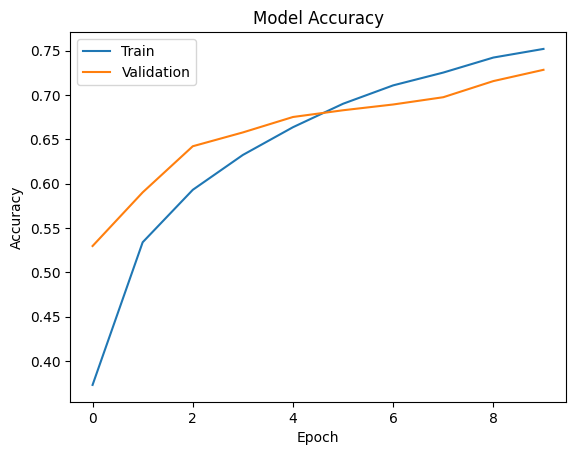

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


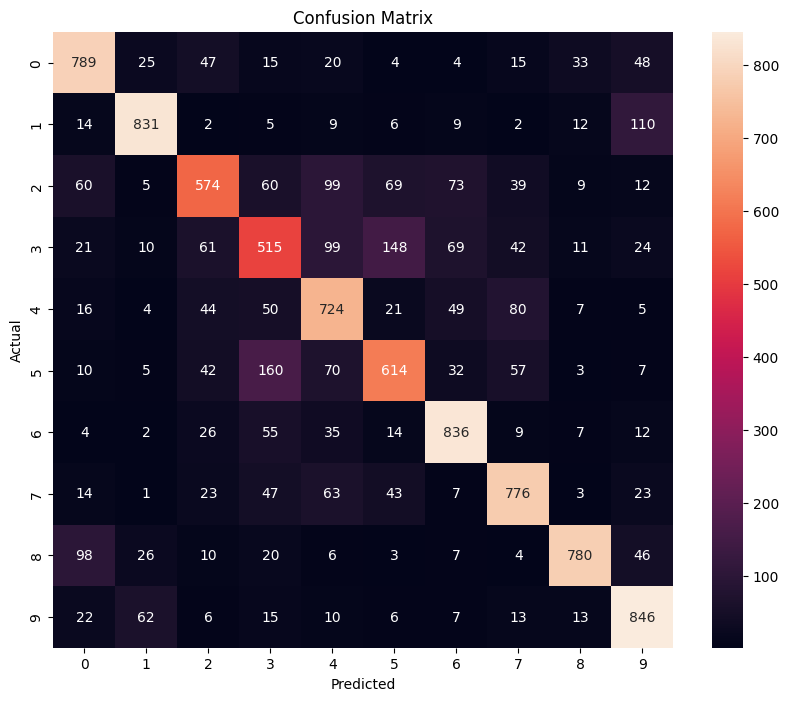

In [10]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1000
           1       0.86      0.83      0.84      1000
           2       0.69      0.57      0.63      1000
           3       0.55      0.52      0.53      1000
           4       0.64      0.72      0.68      1000
           5       0.66      0.61      0.64      1000
           6       0.76      0.84      0.80      1000
           7       0.75      0.78      0.76      1000
           8       0.89      0.78      0.83      1000
           9       0.75      0.85      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



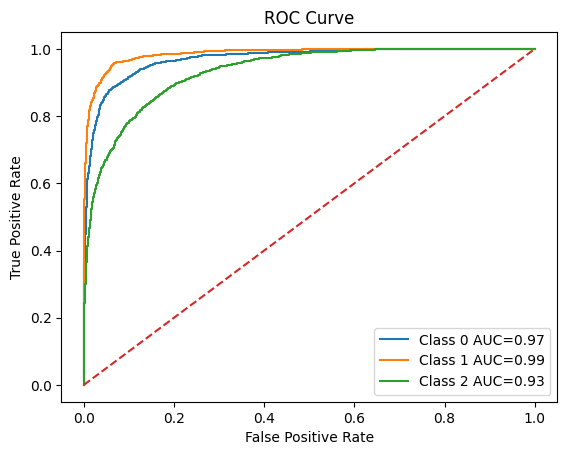

In [12]:
y_test_bin = label_binarize(y_true, classes=range(10))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label="Class %d AUC=%0.2f"%(i, roc_auc[i]))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()